# Preliminaries

In [180]:
import numpy as np
# handle numpy 1.x and 2.x
try:
    from numpy import trapezoid as trapz
except ImportError:
    from numpy import trapz  # NumPy < 2.0

import os, gmsh, time

from mpi4py import MPI
from scipy.interpolate import LinearNDInterpolator
from petsc4py import PETSc

import dolfinx
import dolfinx.mesh
import dolfinx.io
from dolfinx.io import gmsh as gmshio, XDMFFile, VTXWriter
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
from dolfinx.fem import (
    Constant, Function, functionspace, dirichletbc,
    locate_dofs_topological, locate_dofs_geometrical,
    form, Expression, assemble_scalar,
)
from dolfinx.fem import Expression as FEMExpression
from dolfinx.fem.petsc import NonlinearProblem, assemble_vector, set_bc

import ufl
from ufl import (inner, grad, div, sym, tr, det, inv, dot, sqrt,
                 indices, as_tensor, split, derivative,
                 Identity, SpatialCoordinate, FacetNormal,
                 TestFunction, TestFunctions, TrialFunction,
                 Measure, dx, ds, dS,
                 Jacobian, min_value)

import basix.ufl

# DOLFIN_EPS no longer exists; use numpy's machine epsilon instead
DOLFIN_EPS = float(np.finfo(np.float64).eps)

In [181]:
# plotting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size = 18
params = {
    'legend.fontsize': size * 0.75,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{mathrsfs,bm}',
    'axes.labelsize': size,
    'axes.titlesize': size,
    'xtick.labelsize': size * 0.875,
    'ytick.labelsize': size * 0.875,
    'axes.titlepad': 25,
    'animation.embed_limit': 2**128,
}
plt.rcParams.update(params)

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot) includes:
- converting to notebook format for easier on-the-fly analysis, 
- switching to gmsh for modern meshing,
- restricting to _steady flows_, 
- rewriting the FSI solver to be monolithic, 
- treating pressure inlet as Neumann BC, 
- implementing Carreau viscosity model for fluid,
- implementing 2D restriction of neo-Hookean solid,
- adding steady analytical solution comparisons,
- various other small improvements.

Next refactor (Spring 2026) by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Claude) includes
- coverting to dolfinx/next-gen FEniCS.

If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert ALE-FSIx_2D_steady.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `ALE-FSIx_2D_steady.py`.

## Introduction

Sketch of the geometry and notation.

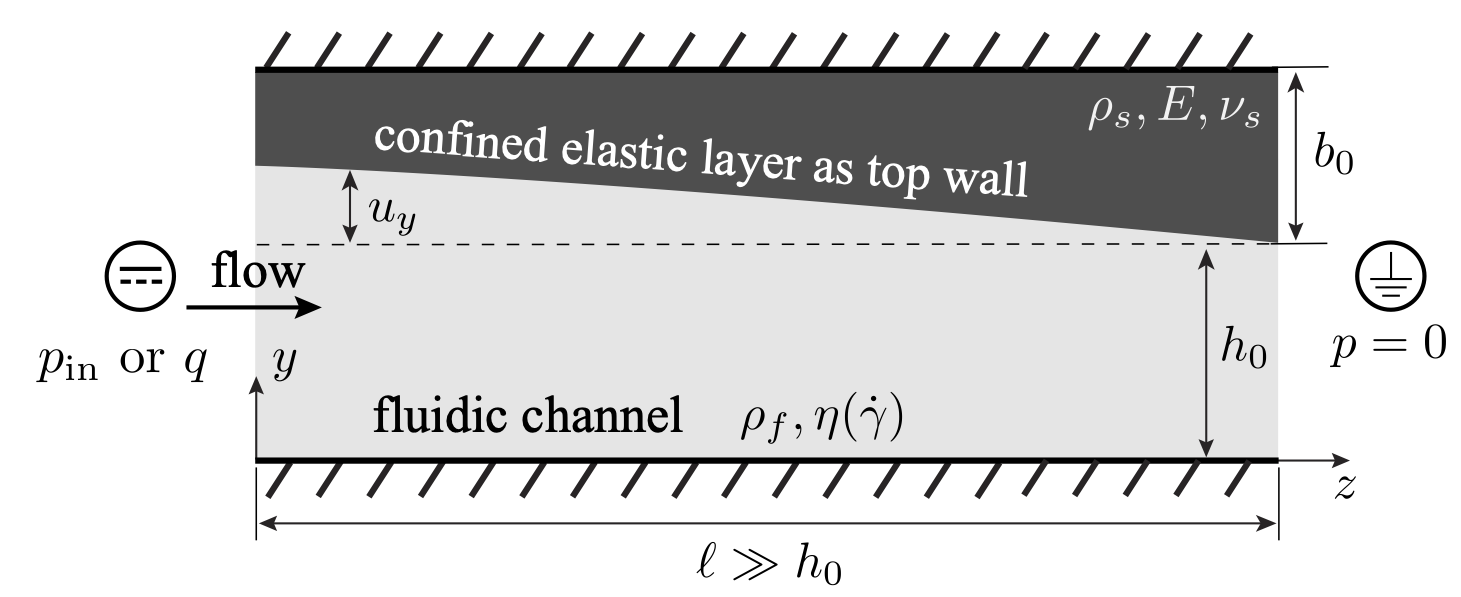

<span style="color: red">WARNING:</span> Carreau model is only implemented in the numerics. The theory relies on the power-law approximation &amp; Winkler-foundation elastic model.

# Problem setup

## Simulation settings

### Data storage

In [182]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output_steady/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output_steady/


### Algorithmic settings

Shouldn't require changing.

In [183]:
mesh_approach   = "SPLIT"    # mesh elasticity approach; "SPLIT" or "BLENDED"
                             # SPLIT: solid law in solid, mesh law in fluid (physically cleaner)
                             # BLENDED: smooth chi_f-weighted mix across full domain

LSIC            = False      # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB   = True       # Backflow stabilization for fluid
SUPG            = False      # Streamline Upwind Petrov-Galerkin stabilization for fluid
                             # not needed for low Re flow

FLUID_MODE_ONLY = False      # A debugging option to run only fluid problem

print("============================ INFO ===========================")
print(f"Mesh elasticity approach: {mesh_approach}")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
if FLUID_MODE_ONLY:
    print("-------------------------------------------------------------")
    print("WARNING: Running in FLUID MODE ONLY (no solid coupling)")
print("=============================================================")

============================ INFO ===========================
Mesh elasticity approach: SPLIT
SUPG stabilization:       OFF
LSIC stabilization:       OFF
Backflow stabilization:   ON


### Parameters defining domain geometry

In [184]:
# Channel/wall dimensions (see figure):
h0 = 0.01
b0 = h0
l  = 75*h0  # 50

# Helper constants for geometry definitions:
SOLID_TOP    = h0 + b0
SOLID_BOTTOM = h0

# Desired resolution of mesh:
N = 100  # 600
# Refine near inlet in SOLID domain only?
inlet_refinement_solid_only = False
inlet_refinement = 0.5  # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33  # 1 = no refinement, 1/() times finer

# Geometry-scale tolerance for subdomains:
d_tol = h0 * 1e-8

### Material properties (dimensional)

The solid is linearly elastic (with materia constants $E_s$, $\nu_s$).

The fluid is a generalized Newtonian fluid with shear-thinning behavior described by the Carreau model:
\begin{align*}
     \eta(\dot{\gamma}) 
     &= \eta_{\infty} + \left(\eta_0-\eta_{\infty}\right) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \right\} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) |\lambda \dot{\gamma}|^{n-1} \right\}, \qquad |\lambda \dot{\gamma}| \gg 1 \\
     &= \eta_{0} |\lambda \dot{\gamma}|^{n-1}\qquad\qquad\;\;\; \beta \ll 1,\quad |\lambda \dot{\gamma}| \gg 1.
\end{align*}

In [185]:
# Elasticity model for real solid:
ELASTICITY_MODEL = "NEOH"  # "STVK" for Saint-Venant--Kirchhoff 
                           # "NEOH" for neo-Hookean, more robust than STVK

# Elastic solid's properties:
E_s        = 1e5                         # Young's modulus
nu_s       = 0.45                        # Poisson ratio
mu_s_val   = E_s / (2 * (1 + nu_s))      # Shear modulus
K_val      = E_s / (3 * (1 - 2 * nu_s))  # Bulk modulus
rho_s0_val = 1e4

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f_val     = 0.5
eta_f_0_val   = 1.0
eta_f_inf_val = 0.0
n_val         = 1.0
lam_r_val     = 0.0
# Consistency index for power-law approximation:
m_plaw_val    = eta_f_0_val * lam_r_val**(n_val - 1)

### Boundary conditions (analytical)

We use the analytical solution for the axial velocity in the _power-law regime_ from, e.g., "[Non-Newtonian fluid&ndash;structure interactions: Static response of a microchannel due to internal flow of a power-law fluid](https://dx.doi.org/10.1016/j.jnnfm.2018.12.008)" (preprint [arXiv:1809.09065](https://arxiv.org/arXiv:1809.09065)).
The flow rate&ndash;pressure drop relation in the rigid case is thus
$$
    q = \int_0^{h_0} v_z \, dy = \frac{1}{2^{1+1/n}(2 + 1/n)} \left(\frac{\Delta p}{\ell} \frac{h_0^{1 + 2n}}{m}\right)^{1/n},
$$
where $m = \eta_0 \lambda^{n-1}$, valid for $\beta = \eta_\infty/\eta_0 \ll 1$ and $|\lambda \dot{\gamma}| \sim Cu \gg 1$.
Thus
$$
    v_z(y) %= \frac{h_0^{2+1/n}}{2^{1+1/n}(2+1/n)} \frac{(2+1/n)}{h_0(1+1/n)} \left(\frac{\Delta p}{\ell m}\right)^{1/n} \left(1-\left| \frac{2 y}{h_0}-1\right|^{1+1/n}\right) ,
    = \frac{q}{h_0} \frac{(2+1/n)}{(1+1/n)} \left(1-\left| \frac{2 y}{h_0}-1\right|^{1+1/n}\right) ,
$$

In [186]:
# Steady pressure BC magnitude (used when FLOW_OR_PRESSURE == "PRESSURE"):
p_amp_val        = 2e5
# Steady flow-rate magnitude (used when FLOW_OR_PRESSURE == "FLOW"):
q_amp_val        = 0.025

# Choose flow- or pressure-controlled inlet forcing:
FLOW_OR_PRESSURE = "PRESSURE"  # "FLOW" or "PRESSURE"

# Load ramping improves Newton robustness by reusing the previous converged state
# as the initial guess for the next load factor.
# load_factors = [0.05, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 1.0]
# load_factors = [0.1, 0.3, 0.7, 1.0]
load_factors   = [1.0]   # one-shot (works if Newton converges from zero)

### Dimensionless numbers

In [187]:
# Choose characteristic scales consistently with the active inlet control mode.
# This keeps the nondimensional diagnostics comparable between FLOW and PRESSURE runs.
if FLOW_OR_PRESSURE == "FLOW":
    q_c   = q_amp_val
    v_c   = q_c / h0
    p_c   = m_plaw_val * l * (q_c**n_val) / h0**(2*n_val + 1)
    dp_rigid = float(2**(1 + 1/n_val) * (2 + 1/n_val)) * p_c
    q_rigid  = q_c
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c   = p_amp_val
    q_c   = ((p_c / l) * (h0**(2*n_val + 1) / m_plaw_val))**(1/n_val)
    v_c   = q_c / h0
    dp_rigid = p_c
    q_rigid  = q_c / float(2**(1 + 1/n_val) * (2 + 1/n_val))
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [188]:
epsilon_f = h0/l                                              # Fluid (inverse) aspect ratio
epsilon_s = b0/l                                              # Solid (inverse) aspect ratio

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s_val/l**2) # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s_val)                   # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s_val/l)                  # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
alpha = float(p_c/(h0/C_w))                                   # Compliance number

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/eta_f**2)      # Reynolds number
Re = float(epsilon_f * rho_f_val * v_c * h0/eta_f_0_val) 
#Re = float(Wo**2 * alpha/gamma)                              # Only if unsteady

beta = float(eta_f_inf_val/eta_f_0_val)                       # Carreau viscosity ratio
Cu = float(lam_r_val * v_c/h0)                                # Carreau number

print("============================ INFO ===========================")
print(f">>> Using {FLOW_OR_PRESSURE}-controlled BC & scales.")
print("-------------------------------------------------------------")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"α   = {alpha:.5f} (compliance #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print(f"β   = {beta:.5f} (viscosity ratio)")
print(f"Cu  = {Cu:.5f} (Carreau #)")
print("=============================================================")

============================ INFO ===========================
>>> Using PRESSURE-controlled BC & scales.
-------------------------------------------------------------
ε_f = 0.01333
ε_s = 0.01333
θ   = 0.00039
α   = 0.52727 (compliance #)
εRe = 0.00178 (Reynolds #)
β   = 0.00000 (viscosity ratio)
Cu  = 0.00000 (Carreau #)


## Analytical solutions: for comparisons, etc

### Rigid channel

Implementing the steady 2D channel flow solution for the pressure:
$$
    p(z) = \frac{\Delta p}{\ell}(\ell - z).
$$
The axial velocity is as given above.

In [189]:
def p_rigid_py(x, y=0.0):
    # Rigid-channel pressure (linear drop).
    return (dp_rigid / l) * (l - x) if y < h0 + d_tol else 0.0

def v_rigid_py(x_arr):
    """
    Rigid-channel power-law velocity profile.
    x_arr : shape (2, N) array (from dolfinx interpolation).
    Returns shape (2, N) velocity array.
    """
    vals = np.zeros_like(x_arr)
    mask = x_arr[1] < h0 + d_tol
    y    = x_arr[1, mask]
    vals[0, mask] = (q_rigid / h0 * (2 + 1/n_val) / (1 + 1/n_val)
                     * (1 - np.abs(1 - 2*y/h0)**(1 + 1/n_val)))
    return vals

### Compliant channel

Implementing Eq. (41) and related results from "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)):
$$
    %-\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}w^n},
    -\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}},\quad p(\ell) = 0,
$$
which can be integrated directly when $q$ is given (flow-rate control), or differentiated once and solved as 
$$
    \frac{d}{d{z}}\left\{ [h_0 + \mathcal{C} p(z)]^{1+2n} \frac{dp}{d{z}}  \right\} = 0,\quad p(0) = \Delta p,\quad p(\ell) = 0,
$$
when $\Delta p$ is given (pressure-drop control).

In [190]:
# Common factor in both the p_sh pressure formula (FLOW) and q_sh flux formula (PRESSURE).
nhat_factor = 2**(1 + n_val) * (2 + 1/n_val)**n_val

if FLOW_OR_PRESSURE == "PRESSURE":
    def p_sh_py(x, y=0.0):
        # Steady soft-hydraulic pressure (pressure-controlled).
        arg = (1 + alpha)**(2 + 2*n_val) * (1 - x/l) + x/l
        return p_c / alpha * (arg**(1/(2 + 2*n_val)) - 1)

    # dp/dx at x=0 by direct differentiation of p_sh_py:
    #   p(x) = (p_c/α) · [(1+α)^s·(1-x/l) + x/l]^(1/s) − p_c/α,  s = 2+2n
    #   dp/dx|_{x=0} = (p_c/(α·l·s)) · (1+α)^(1−s) · (1 − (1+α)^s)
    #                = (p_c/(α·l·s)) · [(1+α)^{−(1+2n)} − (1+α)]
    # h(0) = h0 + C_w·p_sh(0) = h0 + C_w·p_c = h0·(1+α)  [since α = C_w·p_c/h0]
    dp_shdz0 = (p_c / (alpha * l * (2 + 2*n_val))) * ((1 + alpha)**(-(1 + 2*n_val)) - (1 + alpha))
    q_sh = ((-dp_shdz0)
            * (h0 * (1 + alpha))**(1 + 2*n_val) / m_plaw_val
            / nhat_factor)**(1/n_val)

elif FLOW_OR_PRESSURE == "FLOW":
    nhat = nhat_factor * (2 + 2*n_val)
    def p_sh_py(x, y=0.0):
        # Steady soft-hydraulic pressure (flow rate-controlled).
        return p_c / alpha * ((1 + nhat * alpha * (1 - x/l))**(1/(2 + 2*n_val)) - 1)

    # Flow rate is prescribed, so the soft-hydraulic q equals the imposed value.
    q_sh = q_rigid

## Domain and mesh

Gmsh-based geometry & mesh.

In [191]:
from build_gmsh_x import (
    build_gmsh_x,
    FLUID_FLAG, SOLID_FLAG,
    INTERFACE_TAG, WALL_B_TAG, WALL_T_TAG,
    INFLOW_TAG, OUTFLOW_TAG, WALL_L_TAG, WALL_R_TAG,
)

mesh, cell_tags, facet_tags = build_gmsh_x(
    N,
    [0.0, l, 0.0, h0 + b0, h0],   # NOTE: IFACE = h0 (= b0 in steady notebook)
    DataFolder + "fsi_rect",
    inlet_refinement=inlet_refinement,
    inlet_refinement_solid_only=inlet_refinement_solid_only,
    interface_refinement=interface_refinement,
)

d   = mesh.geometry.dim
n_y = FacetNormal(mesh)
I   = Identity(d)

INFLOW    = INFLOW_TAG
OUTFLOW   = OUTFLOW_TAG
INTERFACE = INTERFACE_TAG

# dolfinx expressions for material and BC parameters and BCs (all constant in this case)
mu_s   = Constant(mesh, mu_s_val)
K      = Constant(mesh, K_val)
rho_s0 = Constant(mesh, rho_s0_val)

rho_f     = Constant(mesh, rho_f_val)
eta_f_0   = Constant(mesh, eta_f_0_val)
eta_f_inf = Constant(mesh, eta_f_inf_val)
n         = Constant(mesh, n_val)
lam_r     = Constant(mesh, lam_r_val)
m_plaw    = eta_f_0 * lam_r**(n - 1.0)

p_amp = Constant(mesh, p_amp_val)
q_amp = Constant(mesh, q_amp_val)

# For load ramping: update p_amp.value or q_amp.value inside the load loop
# (no reassembly needed).

Info    : Found interface curve 4: x = [-0.000000, 0.750000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.31656s, CPU 0.217772s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.117906s, CPU 0.053325s)
Info    : 943 nodes 2134 elements
Info    : Writing 'not-ready-for-github/simulation_output_steady/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output_steady/fsi_rect.msh'


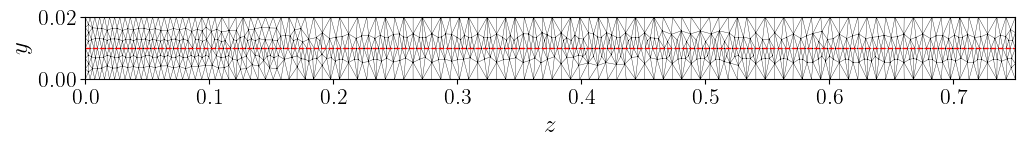

In [192]:
# Visualize the mesh (dolfinx: matplotlib triangulation instead of dolfin.plot):
coords = mesh.geometry.x                        # shape (n_pts, 3), z-column=0 for 2D
num_cells = mesh.topology.index_map(2).size_local
mesh.topology.create_connectivity(2, 0)
c2v = mesh.topology.connectivity(2, 0)
triangles = np.array([c2v.links(i) for i in range(num_cells)])

triang = tri.Triangulation(coords[:, 0], coords[:, 1], triangles)

fig, ax = plt.subplots(figsize=(12, 6))
ax.triplot(triang, linewidth=0.25, color='k')
ax.plot(np.linspace(0, l, 10), np.ones(10)*h0,
        linestyle='dashed', linewidth=1.0, color='red')
ax.set_aspect('auto')
ax.set_xlim(0, l)
ax.set_ylim(0, h0 + b0)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$y$')
plt.gca().set_aspect(2.5/1)
plt.show()

In [193]:
# Define subdomain locator functions for BC application and diagnostics.
def wall_b_locator(x):
    return x[1] < d_tol

def wall_t_locator(x):
    return x[1] > SOLID_TOP - d_tol

def wall_l_locator(x):   # solid left wall
    return np.logical_and(x[0] < d_tol, x[1] > SOLID_BOTTOM - d_tol)

def wall_r_locator(x):   # solid right wall
    return np.logical_and(x[0] > l - d_tol, x[1] > SOLID_BOTTOM - d_tol)

def inflow_locator(x):
    return np.logical_and(x[0] < d_tol, x[1] < SOLID_BOTTOM + d_tol)

def outflow_locator(x):
    return np.logical_and(x[0] > l - d_tol, x[1] < SOLID_BOTTOM + d_tol)

def solid_closure_locator(x):
    return (np.logical_and(x[1] > SOLID_BOTTOM - d_tol, x[1] < SOLID_TOP + d_tol) &
            np.logical_and(x[0] > 0 - d_tol,   x[0] < l + d_tol))

def solid_interior_locator(x):
    return (np.logical_and(x[1] > SOLID_BOTTOM + d_tol, x[1] < SOLID_TOP + d_tol) &
            np.logical_and(x[0] > 0 + d_tol,   x[0] < l - d_tol))

def fluid_interior_locator(x):
    return (np.logical_and(x[1] > d_tol,              x[1] < SOLID_BOTTOM - d_tol) &
            np.logical_and(x[0] > 0 + d_tol, x[0] < l - d_tol))

def fs_interface_locator(x):
    return np.abs(x[1] - SOLID_BOTTOM) < d_tol

In [194]:
# Define measures for integration, with appropriate quadrature degree.
qd = 5
dx = Measure("dx", domain=mesh, subdomain_data=cell_tags,
             metadata={"quadrature_degree": qd})
ds = Measure("ds", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})
dS = Measure("dS", domain=mesh, subdomain_data=facet_tags,
             metadata={"quadrature_degree": qd})

# Shorthand used throughout the variational forms (unchanged from original):
dX   = dx(SOLID_FLAG)   # solid volume integral
dy   = dx               # reference-config volume integral (fluid + solid)
ds_y = ds               # reference-config surface integral

In [195]:
# Check exterior (in/outlet) and interior (interface) measures:
print("======================== DIAGNOSTICS ========================")
print("Checking identification of boundary surfaces ...")
print("|Γ_in|  =", assemble_scalar(form(Constant(mesh, 1.0) * ds(INFLOW))),  '; h0 =', h0)
print("|Γ_out| =", assemble_scalar(form(Constant(mesh, 1.0) * ds(OUTFLOW))), '; h0 =', h0)
print("|Γ_fs|  =", assemble_scalar(form(Constant(mesh, 1.0) * dS(INTERFACE))), '; l =', l)

# chi_f is defined in CELL 19 (1 in fluid, 0 in solid).
# Check '+'/'-' fluid-side distribution via mesh topology to avoid UFL entity_maps
# issue with standalone one-sided interior-facet forms.
# DOLFINx convention: '+' = cell with lower global index at each facet.
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
f2c          = mesh.topology.connectivity(mesh.topology.dim - 1, mesh.topology.dim)
fluid_cells  = set(cell_tags.find(FLUID_FLAG).tolist())
iface_facets = facet_tags.find(INTERFACE_TAG)

n_plus_fluid = n_minus_fluid = 0
for fac in iface_facets:
    cells = f2c.links(int(fac))
    c_plus = int(min(cells))           # lower global index → '+' side
    n_plus_fluid  += int(c_plus in fluid_cells)
    n_minus_fluid += int(c_plus not in fluid_cells)

n_total = len(iface_facets)
print()
print("Interface '+'/'-' fluid-side distribution (occ.fragment() → non-uniform):")
print(f"  fluid on '-': {n_minus_fluid}/{n_total} facets  ({100*n_minus_fluid/n_total:.1f}%)")
print(f"  fluid on '+': {n_plus_fluid}/{n_total} facets  ({100*n_plus_fluid/n_total:.1f}%)")
print("(chi_f-based will handle the traction selection handles mixed orientation correctly)")
print("=============================================================")

======================== DIAGNOSTICS ========================
Checking identification of boundary surfaces ...
|Γ_in|  = 0.009999999999999998 ; h0 = 0.01
|Γ_out| = 0.009999999999999998 ; h0 = 0.01
|Γ_fs|  = 0.7500000000000006 ; l = 0.75

Interface '+'/'-' fluid-side distribution (occ.fragment() → non-uniform):
  fluid on '-': 108/244 facets  (44.3%)
  fluid on '+': 136/244 facets  (55.7%)
(chi_f-based will handle the traction selection handles mixed orientation correctly)


# Variational problem definitions

## Elements, function spaces, and variables

In [196]:
# Mixed function space for the monolithic fluid-structure-ALE problem.
# Subspace ordering (v, p, u) is fixed here; 
# Z.sub(0)=velocity, Z.sub(1)=pressure, Z.sub(2)=displacement.
cell_name = mesh.topology.cell_name()

# velocity  (P2 vector)
Ve  = basix.ufl.element("Lagrange", cell_name, 2, shape=(d,))
# pressure  (P1 scalar — Taylor-Hood P2/P1 pair)
Qe  = basix.ufl.element("Lagrange", cell_name, 1)
# displacement (P2 vector, same order as velocity)
Ue  = basix.ufl.element("Lagrange", cell_name, 2, shape=(d,))

Ze = basix.ufl.mixed_element([Ve, Qe, Ue])
Z  = functionspace(mesh, Ze)

# Define the solution and test functions.
z          = Function(Z, name="z")
v, p, u    = split(z)
dv, dp, du = TestFunctions(Z)

## ALE kinematics (change of variables)

In [197]:
# ALE notation used throughout (follows Bazilevs et al.):
#   y = reference (mesh) coordinate  — what FEniCS/dolfinx sees
#   x = spatial (deformed) coordinate = y + u
#   X = material (Lagrangian) coordinate  (not used explicitly here)
# Built-in differential operators (grad, div, …) and integration measures (dx, ds, …)
# are w.r.t. y (the mesh FEniCS sees), so spatial derivatives must be mapped by:
#   grad_x(f) = grad_y(f) · inv(grad_y(x)) = grad_y(f) · inv(F_m)
# where F_m = grad_y(x) = I + grad_y(u) is the ALE mesh deformation gradient.

# Note: dx always integrates over the reference mesh. Integrals over the spatial
# configuration must include the Jacobian det_dxdy = det(F_m) explicitly.

grad_y   = grad
y        = SpatialCoordinate(mesh)
x        = y + u
det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f), inv(grad_y(x)))

def div_x(f):
    return tr(grad_x(f))

def div_x_tens(f):
    i, j = indices(2)
    return as_tensor(grad_x(f)[i, j, j], (i,))

## Boundary conditions (simulation)

In [198]:
fdim = mesh.topology.dim - 1
mesh.topology.create_connectivity(fdim, mesh.topology.dim)

# Collapse subspaces (needed for Function-valued BCs on vector subspaces)
Z0, _ = Z.sub(0).collapse()   # velocity
Z1, _ = Z.sub(1).collapse()   # pressure
Z2, _ = Z.sub(2).collapse()   # displacement

# Zero-valued Function objects (reused across multiple BCs)
zero_vel_fn  = Function(Z0)   # zero velocity
zero_disp_fn = Function(Z2)   # zero displacement
zero_p_fn    = Function(Z1)   # zero pressure


# ---- Velocity BCs in fluid: no-slip walls (Pattern B) ----
def vel_bc_facets(facets):
    """Zero-velocity Dirichlet BC on an array of facet entity indices."""
    dofs = locate_dofs_topological((Z.sub(0), Z0), fdim, facets)
    return dirichletbc(zero_vel_fn, dofs, Z.sub(0))

# Combine facet arrays directly instead of merging MeshTags.
ns_facets = np.concatenate([facet_tags.find(WALL_B_TAG), facet_tags.find(WALL_T_TAG)])
s_facets  = np.concatenate([facet_tags.find(WALL_L_TAG), facet_tags.find(WALL_R_TAG)])

bc_v_ns_walls = vel_bc_facets(ns_facets)   # no-slip: bottom fluid + top solid wall
bc_v_s_walls  = vel_bc_facets(s_facets)    # zero velocity: solid lateral walls

# ---- Velocity BCs in solid: interior + interface (Pattern C, geometric) ----
# Forces v = 0 throughout the solid domain (steady ALE: mesh velocity = 0
# everywhere, so fluid-solid kinematic condition gives v_fluid = 0 at interface).
dofs_v_solid_int = locate_dofs_geometrical(
    (Z.sub(0), Z0), solid_interior_locator)
bc_v_solid_int = dirichletbc(zero_vel_fn, dofs_v_solid_int, Z.sub(0))

dofs_v_iface = locate_dofs_geometrical(
    (Z.sub(0), Z0), fs_interface_locator)
bc_v_iface = dirichletbc(zero_vel_fn, dofs_v_iface, Z.sub(0))

bcs_f = [bc_v_ns_walls, bc_v_s_walls, bc_v_solid_int, bc_v_iface]

# ---- Inlet BC: FLOW → velocity profile; PRESSURE → Neumann (no Dirichlet) ----
if FLOW_OR_PRESSURE == "FLOW":
    v_in_fn = Function(Z0, name="v_in")

    def v_in_array(x, q_now):
        vals = np.zeros((2, x.shape[1]), dtype=dolfinx.default_scalar_type)
        mask = x[1] < h0 + d_tol
        vals[0, mask] = (q_now / h0 * (2 + 1/n_val) / (1 + 1/n_val)
                         * (1 - np.abs(2*x[1, mask]/h0 - 1)**(1 + 1/n_val)))
        return vals

    def update_v_in(q_now):
        """Re-interpolate v_in_fn for the current flow rate q_now."""
        v_in_fn.interpolate(lambda x: v_in_array(x, q_now))

    update_v_in(q_amp_val)   # initialise to full amplitude

    dofs_v_in = locate_dofs_topological(
        (Z.sub(0), Z0), fdim, facet_tags.find(INFLOW_TAG))
    bc_in = dirichletbc(v_in_fn, dofs_v_in, Z.sub(0))
    bcs_in = [bc_in]

elif FLOW_OR_PRESSURE == "PRESSURE":
    # Pressure applied as Neumann (traction) in the variational form.
    # p_amp is a Constant; update p_amp.value in the load loop.
    bcs_in = []

# ---- Pressure BC: pin p = 0 inside solid domain (Pattern C, geometric) ----
# IMPORTANT: use y > SOLID_BOTTOM (not solid_interior_locator) to include the
# solid lateral wall nodes (x≈0 and x≈l, y>h0).  solid_interior_locator
# excludes those nodes and leaves their pressure DOFs unconstrained, which
# makes the Jacobian singular at lateral solid walls.
# Interface nodes (y = SOLID_BOTTOM = h0) are deliberately excluded — their
# pressure is the fluid pressure (determined by the flow equations).
def solid_p_locator(x):
    return x[1] > SOLID_BOTTOM + d_tol

dofs_p_solid = locate_dofs_geometrical(
    (Z.sub(1), Z1), solid_p_locator)
bc_p_solid = dirichletbc(zero_p_fn, dofs_p_solid, Z.sub(1))
bcs_p = [bc_p_solid]

# ---- Displacement BCs: u = 0 on all external boundaries (Pattern B) ----
def disp_bc_facets(facets):
    """Zero-displacement Dirichlet BC on an array of facet entity indices."""
    dofs = locate_dofs_topological((Z.sub(2), Z2), fdim, facets)
    return dirichletbc(zero_disp_fn, dofs, Z.sub(2))

bc_u_ns  = disp_bc_facets(ns_facets)
bc_u_s   = disp_bc_facets(s_facets)
bc_u_in  = disp_bc_facets(facet_tags.find(INFLOW_TAG))
bc_u_out = disp_bc_facets(facet_tags.find(OUTFLOW_TAG))
bcs_s    = [bc_u_ns, bc_u_s, bc_u_in, bc_u_out]

# In the load loop, update the amplitude then resolve:
#   PRESSURE mode:  p_amp.value = load_factor * p_amp_val
#   FLOW mode:      update_v_in(load_factor * q_amp_val)
# (No BC recreation needed — Function/Constant values update by reference.)

In [199]:
# Define chi_f that keeps track of fluid domain vs solid domain in the monolithic formulation.
V0 = functionspace(mesh, basix.ufl.element("DG", cell_name, 0))
chi_f = Function(V0, name="chi_f")   # 1 in fluid, 0 in solid
fluid_dofs_dg = np.concatenate([V0.dofmap.cell_dofs(c)
                                 for c in cell_tags.find(FLUID_FLAG)])
chi_f.x.array[fluid_dofs_dg] = 1.0
chi_f.x.scatter_forward()
# chi_s = 1 - chi_f  (UFL expression: 1 in solid, 0 in fluid)

## Monolithic residual

### Solid and mesh (elasticity) subproblems

In [200]:
F_s = I + grad_y(u)           # solid deformation gradient  (= mesh deformation gradient)
F_m = F_s                     # ALE mesh deformation gradient (same in monolithic FSI)
Eps_s = 0.5*(F_s.T*F_s - I)   # Green-Lagrange strain tensor

if ELASTICITY_MODEL == "STVK":
    # Linear-in-strain Saint-Venant--Kirchhoff model (simple, less robust for large strain)
    S_solid = K*tr(Eps_s)*I + 2.0*mu_s*(Eps_s - tr(Eps_s)*I/3.0)

elif ELASTICITY_MODEL == "NEOH":
    J_s  = det(F_s)
    C_s  = F_s.T * F_s
    # Plane strain assumption implies C_33 = 1, hence I1_3D = tr(C_2D) + 1.
    # This +1 is not appropriate for plane stress or axisymmetric formulations.
    I1   = tr(C_s) + 1.0
    Cinv = inv(C_s)

    # Isochoric-volumetric split for compressible Neo-Hookean response.
    S_iso   = mu_s * J_s**(-2.0/3.0) * (I - (1.0/3.0)*I1*Cinv)
    # Quadratic volumetric potential U=(K/2)*(J-1)^2:
    S_vol   = K * (J_s - 1.0) * J_s * Cinv
    # Alternative (Simo & Hughes 1998): S_vol = 0.5*K*(J_s**2 - 1.0)*Cinv
    S_solid = S_iso + S_vol

else:
    raise ValueError("Unknown value of ELASTICITY_MODEL!")

# Mesh pseudo-elastic stiffness increases as det(F_m) decreases, protecting
# badly deformed elements from inversion during ALE updates.
m_jac_stiff_pow = Constant(mesh, 3.0)
# The factor scales with alpha so that the mesh stiffness grows with the
# expected deformation magnitude — without this scaling Newton diverges for
# large compliance numbers.
mesh_stiffness_factor = Constant(mesh, 0.5) #10.0 * alpha
K_m   = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
mu_m  = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
S_mesh = K_m*tr(Eps_s)*I + 2.0*mu_m*(Eps_s - tr(Eps_s)*I/3.0)

if mesh_approach == "SPLIT":
    # Solid law in solid subdomain, mesh law in fluid subdomain.
    res_s = (inner(F_s*S_solid, grad_y(du)) * dx(SOLID_FLAG)
             + inner(F_s*S_mesh,  grad_y(du)) * dx(FLUID_FLAG))

elif mesh_approach == "BLENDED":
    # Single blended stress field across full domain.
    chi_s   = 1.0 - chi_f                       # UFL expression: 1 in solid, 0 in fluid
    S_blend = chi_s*S_solid + chi_f*S_mesh
    res_s   = inner(F_s*S_blend, grad_y(du)) * dx

else:
    raise ValueError(f"Unknown mesh_approach: {mesh_approach!r}")

### Fluid subproblem


In [201]:
# Steady ALE: mesh velocity = 0.
vhat_m = Constant(mesh, np.zeros(d))

# Shear rate magnitude.
def gamma_dot(v_):
    # DOLFIN_EPS avoids sqrt(0) in the Jacobian.
    return sqrt(2.0*inner(sym(grad_x(v_)), sym(grad_x(v_))) + DOLFIN_EPS)

# Carreau viscosity model (generalizes power-law and Newtonian).
def mu_eff(v_):
    return (eta_f_inf + (eta_f_0 - eta_f_inf)
            * (1.0 + (lam_r*gamma_dot(v_))**2.0)**((n - 1.0)/2.0))

# Cauchy stress in the current configuration:
sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

# ALE advection velocity and steady material derivative (no explicit time term):
v_adv = v - vhat_m
DvDt  = dot(grad_x(v), v_adv)
# Stokes flow limit (zero convection): replace the above with
# DvDt = Constant(mesh, np.zeros(d))

# Galerkin weak form of steady incompressible Navier-Stokes in ALE coordinates:
resGal_f = (rho_f*dot(DvDt, dv)
            + inner(sigma_f, grad_x(dv))
            + dp*div_x(v)) * det_dxdy * dx(FLUID_FLAG)
# Note: this is the IBP form (sigma_f : grad_x(dv)).
# The equivalent NOT-IBP form is:
# resGal_f = (rho_f*dot(DvDt, dv)
#             - inner(div_x_tens(sigma_f), dv)
#             + dp*div_x(v)) * det_dxdy * dx(FLUID_FLAG)

# Deformed mesh size tensor in the spatial configuration:
J_cov    = Jacobian(mesh)
dxi_dy_m = inv(J_cov)
dxi_dx_m = dxi_dy_m * inv(grad_y(x))
G        = dxi_dx_m.T * dxi_dx_m

# Strong residual used by SUPG/PSPG-like stabilization terms:
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

Cinv_stab = Constant(mesh, 1.0)
tau_M = 1.0 / sqrt(inner(rho_f*v_adv, G*(rho_f*v_adv))
                   + Cinv_stab*(eta_f_0**2)*inner(G, G) + DOLFIN_EPS)
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv), v_adv)
                  + grad_x(dp)) * det_dxdy * dx(FLUID_FLAG)

tau_C     = 1.0 / (tr(G)*tau_M + DOLFIN_EPS)
resLSIC_f = tau_C*div_x(v)*div_x(dv) * det_dxdy * dx(FLUID_FLAG)

# Backflow-stable Neumann term on outflow:
dsx_dsy_n_x  = det_dxdy * inv(F_m.T) * n_y
v_adv_minus  = min_value(dot(v_adv, dsx_dsy_n_x), Constant(mesh, 0.0))
gm           = Constant(mesh, 1.0)
resOutflow_f = -gm * dot(rho_f*v_adv_minus*dv, v) * ds(OUTFLOW)

# Assemble fluid residual with optional stabilization blocks:
res_f = resGal_f
if SUPG:
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
if BACKFLOW_STAB:
    res_f += resOutflow_f

# In PRESSURE mode, inlet pressure is applied as a consistent traction (Neumann):
if FLOW_OR_PRESSURE == "PRESSURE":
    res_f += -inner(det_dxdy * inv(F_m.T) * (-p_amp * n_y), dv) * ds(INFLOW)

### Coupling

Traction at the fluid–solid interface enforces the stress-balance coupling condition.

In the monolithic formulation each residual block is tested only against its own test function: the fluid block uses `dv` and the solid block uses `du`. Here, `t_ref` is defined as the **fluid traction acting on the solid side** of $\Gamma_{fs}$ (after selecting the fluid/solid sides with `chi_f`). With this convention, the coupling term that enters the solid residual is
$$
    \int_{\Gamma_{fs}} \mathbf{t}_{\mathrm{ref}}\cdot\delta\mathbf{u}_s\,d\Gamma,
$$
so `res_if` uses a **positive** sign. (If `t_ref` were defined with the opposite action/reaction convention, the sign would be negative.)

The "solid onto fluid" term is not added separately here because: (1) the solid momentum residual `res_s` is tested against `du` (solid-side test function), and (2) the kinematic coupling $\mathbf{v}=\hat{\mathbf{v}}_m=0$ at $\Gamma_{fs}$ is already imposed as a Dirichlet BC on velocity.

In [202]:
# Fluid 1st Piola-Kirchhoff stress on each side of the interface:
# P = J * sigma_f * F^{-T}  (Nanson: maps reference-normal to spatial traction)
F_fluid_p   = F_m('+')
F_fluid_m   = F_m('-')
J_fluid_p   = det(F_fluid_p)
J_fluid_m   = det(F_fluid_m)
sigma_fpl_p = sigma_f('+')
sigma_fpl_m = sigma_f('-')

P_fluid_p = J_fluid_p * sigma_fpl_p * inv(F_fluid_p.T)
P_fluid_m = J_fluid_m * sigma_fpl_m * inv(F_fluid_m.T)

# occ.fragment() produces non-uniform '+'/'-' facet orientations: the fluid cell
# is NOT always on the same side.  chi_f (= 1 in fluid, 0 in solid) selects the
# fluid-side Piola traction and (1-chi_f) selects the solid-side test function,
# regardless of how dolfinx assigns '+'/'-' at each interface facet.
t_ref = chi_f('+') * (P_fluid_p * n_y('+')) + chi_f('-') * (P_fluid_m * n_y('-'))
du_s  = (1.0 - chi_f('+')) * du('+') + (1.0 - chi_f('-')) * du('-')

# With t_ref defined as fluid traction acting on the solid, this enters with + sign.
res_if = inner(t_ref, du_s) * dS(INTERFACE)

Define total residuals and complete set of BCs to solve with.

In [203]:
if FLUID_MODE_ONLY:
    # Fluid-only mode: solid mechanics is disabled.
    # u still appears in the ALE kinematics (grad_x, det_dxdy) and must remain
    # a solution variable, but with no solid residual to constrain it we add
    # Tikhonov-style anchors to keep u = 0 throughout:
    #   alpha_u0: mass-like (penalizes large |u|)
    #   alpha_u1: gradient-like (penalizes large grad(u), scaled by h²)
    # Both are proportional to eta_f_0 so they're dimensionally consistent.
    tdim = mesh.topology.dim
    num_cells_local = mesh.topology.index_map(tdim).size_local
    cells_local = np.arange(num_cells_local, dtype=np.int32)
    h_local = float(np.min(mesh.h(tdim, cells_local)))
    h_min = mesh.comm.allreduce(h_local, op=MPI.MIN)

    alpha_u0 = Constant(mesh, 1e3 * eta_f_0_val / h_min)   # mass-like anchor on u
    alpha_u1 = Constant(mesh, 1e2 * eta_f_0_val)           # gradient anchor on u
    
    res  = (res_f
            + alpha_u0 * inner(u, du) * dx
            + alpha_u1 * h_min**2 * inner(grad_y(u), grad_y(du)) * dx)
    bcs  = bcs_f + bcs_in + bcs_p
else:
    # Full FSI mode: fluid + solid + interface coupling residuals combined.
    res  = res_f + res_s + res_if
    bcs  = bcs_f + bcs_in + bcs_p + bcs_s

Dres = derivative(res, z)

# Nonlinear solver for the monolithic problem

Nonlinear solver settings; this is _extremely_ tricky.

In [204]:
problem = NonlinearProblem(
    res, z,
    petsc_options_prefix="steady_",
    bcs=bcs,
    J=Dres,
    jit_options={"cffi_extra_compile_args": ["-O3", "-march=native"]},
    petsc_options={
        # Linear solver: robust direct LU factorization via MUMPS.
        # Highly tuned linear solver settings specific to this FSI problem.
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        # MUMPS tuning for scaling/pivot robustness on ill-conditioned FSI Jacobians.
        "mat_mumps_icntl_8":  77,     # automatic scaling
        "mat_mumps_icntl_24": 1,      # null pivot detection
        "mat_mumps_icntl_13": 1,      # sequential ordering for stability
        "mat_mumps_cntl_1":   0.001,  # small pivot threshold
        "pc_factor_shift_amount": 1e-10,
        "pc_factor_shift_type": "NONZERO",
        # Newton + line search:
        # Use l2 search (minimizes ||F||^2) for stronger nonlinear robustness.
        "snes_type": "newtonls",
        "snes_linesearch_type": "l2",
        "snes_linesearch_max_it":  10,
        "snes_max_linear_solve_fail": 10,
        # Convergence criteria.
        "snes_rtol": 1e-6,
        "snes_atol": 1e-8,
        "snes_max_it": 50,
        # Soft failure: keep notebook flow alive for diagnostics/plotting.
        "snes_error_if_not_converged": 0,
        "ksp_error_if_not_converged":  0,
        # Logging.
        "snes_converged_reason": "",
        "snes_monitor": "",
    },
)

Solve monolithic system. 🤞 This is where the magic happens!

In [205]:
# VTXWriter for velocity, pressure, and solid displacement.
# z.sub(i) shares the mixed DOF array; VTXWriter requires a Function in a
# standard (non-mixed) space — use collapsed subspaces with interpolation.
v_out = Function(Z0, name="v")
p_out = Function(Z1, name="p")
u_out = Function(Z2, name="u")
vfile = VTXWriter(mesh.comm, DataFolder+"velocity.bp",    [v_out], engine="BP4")
pfile = VTXWriter(mesh.comm, DataFolder+"pressure.bp",    [p_out], engine="BP4")
ufile = VTXWriter(mesh.comm, DataFolder+"displacement.bp",[u_out], engine="BP4")

print("="*60, flush=True)
print(f"Starting nonlinear solve with {z.x.array.size} DOFs.", flush=True)
print("="*60, flush=True)

error = False
for index, load_factor in enumerate(load_factors):
    print(f"\n{'-'*60}", flush=True)
    print(f"Trying load factor = {load_factor} ...", flush=True)
    print(f"{'-'*60}", flush=True)

    # Scale forcing by load factor; BC objects are reused and updated by reference.
    if FLOW_OR_PRESSURE == "FLOW":
        update_v_in(load_factor * q_amp_val)
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_amp.value = load_factor * p_amp_val

    # Save last working coefficient vector so we can recover after a hard failure.
    z_last_working = z.x.array.copy()

    try:
        problem.solve()
        reason = problem.solver.getConvergedReason()
        converged = reason > 0
        print(f"  Converged: {converged}  (reason={reason})", flush=True)

        if not converged:
            print("\n" + "="*60, flush=True)
            print("  ⚠️  WARNING: SNES DID NOT CONVERGE  ⚠️", flush=True)
            print("  Plots below are from a non-converged solution; interpret with caution.", flush=True)
            print("="*60 + "\n", flush=True)
            error = True
    except RuntimeError as e:
        print("\n" + "="*60, flush=True)
        print(f"Caught a RuntimeError: {e}", flush=True)
        print(f"\n  ⚠️ Failed on load factor: {load_factor} ⚠️", flush=True)
        if index > 0:
            print(f"  ⚠️ Last load factor before failure: {load_factors[index-1]} ⚠️", flush=True)
        print("  ⚠️ WARNING: FULL LOAD NOT REACHED ⚠️", flush=True)
        print("="*60 + "\n", flush=True)

        z.x.array[:] = z_last_working
        z.x.scatter_forward()
        error = True
        break

    # Refresh post-processing/output fields from mixed solution.
    v_out.interpolate(z.sub(0))
    p_out.interpolate(z.sub(1))
    u_out.interpolate(z.sub(2))
    vfile.write(float(load_factor))
    pfile.write(float(load_factor))
    ufile.write(float(load_factor))

vfile.close()
pfile.close()
ufile.close()

if not error:
    print(f"{'='*60}", flush=True)
    print("  >>>SUCCESS<<< Full load reached! 🎉 🎉 🎉", flush=True)
    print(f"{'='*60}", flush=True)

Starting nonlinear solve with 15083 DOFs.

------------------------------------------------------------
Trying load factor = 1.0 ...
------------------------------------------------------------
  0 SNES Function norm 8.314781899910e+02
  1 SNES Function norm 5.043362567828e+02
  2 SNES Function norm 2.543035668572e+02
  3 SNES Function norm 8.861944855975e+01
  4 SNES Function norm 3.508791242259e+00
  5 SNES Function norm 1.038040435282e-02
  6 SNES Function norm 1.035289723922e-07
  Nonlinear steady_ solve converged due to CONVERGED_FNORM_RELATIVE iterations 6
  Converged: True  (reason=3)
  >>>SUCCESS<<< Full load reached! 🎉 🎉 🎉


### Diagnostics

In [206]:
# ── Mesh Jacobian ──────────────────────────────────────────────────────────────
# V0 (DG0 space) and F_m are defined in the preamble.
J_dg   = Function(V0)
J_expr = FEMExpression(det(F_m), V0.element.interpolation_points)   # property, no ()
J_dg.interpolate(J_expr)
J_vals = J_dg.x.array

# ── Mass conservation on fluid boundaries ──────────────────────────────────────
# v_out is the collapsed velocity Function (Z0) written in the load loop.
# dsx_dsy_n_x = det_dxdy * inv(F_m.T) * n_y  (ALE-mapped outward normal flux).
Q_in    = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)   * ds(INFLOW)))
Q_out   = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)   * ds(OUTFLOW)))
Q_walls  = assemble_scalar(form(dot(v_out, dsx_dsy_n_x)   * (ds(WALL_B_TAG) + ds(WALL_T_TAG))))
Q_FS    = assemble_scalar(form(dot(v_out('+'), n_y('+')) * dS(INTERFACE)))
sum_Q   = float(Q_in + Q_out + Q_walls + Q_FS)

# ── Divergence diagnostics ─────────────────────────────────────────────────────
# Use v = split(z)[0] (UFL expression) so that div_x(v) compiles correctly.
mass_residual = assemble_scalar(form(det_dxdy * div_x(v) * dx(FLUID_FLAG)))

# ── Kinematic mismatch on Γ_fs (should be ≈ 0 with no-penetration BC) ─────────
slip = np.sqrt(assemble_scalar(form(inner(v_out('+'), v_out('+')) * dS(INTERFACE))))

# ── Pressure at sample points along the channel midline y = h0/2 ──────────────
x_test     = np.array([0.0, l/3, l/2, 2*l/3, l])
pts        = np.column_stack([x_test, np.full_like(x_test, h0/2), np.zeros_like(x_test)])
tree       = bb_tree(mesh, mesh.topology.dim)
cell_cands = compute_collisions_points(tree, pts)
coll_cells = compute_colliding_cells(mesh, cell_cands, pts)
# Batch eval: gather one cell per valid point, then call eval once.
valid_mask  = np.array([len(coll_cells.links(i)) > 0 for i in range(len(x_test))])
valid_pts   = pts[valid_mask]
valid_cells = np.array([coll_cells.links(i)[0]
                        for i in range(len(x_test)) if len(coll_cells.links(i)) > 0])
p_computed  = np.full(len(x_test), float('nan'))
if valid_pts.shape[0] > 0:
    p_computed[valid_mask] = p_out.eval(valid_pts, valid_cells).flatten()
p_theory   = [p_sh_py(xi) for xi in x_test]

# ── Print ──────────────────────────────────────────────────────────────────────
print("======================== DIAGNOSTICS ========================")
print(f"det(F) min: {J_vals.min():.6f}            |  "
      f"det(F) max: {J_vals.max():.6f}")
print(f"Number of inverted elements: {sum(J_vals < 0)}  |  "
      f"Number near-inverted (J < 0.3): {sum(J_vals < 0.3)}")

if J_vals.min() < 0.3:
    bad_dofs = np.where(J_vals < 0.3)[0]
    print(f"Problematic DOFs: {bad_dofs[:10]}")
    coords = V0.tabulate_dof_coordinates()
    for di in bad_dofs[:5]:
        print(f"  DOF {di} at ({coords[di, 0]:.4f}, {coords[di, 1]:.4f})")

print()
print(f"Q_in    = {q_rigid:.12e}   (rigid)")
print(f"Q_in    = {float(q_sh):.12e}   (soft hydraulics (plaw))")
print(f"Q_in    = {Q_in:.12e}  (sim, expect < 0),  "
      f"% err={100.0*abs(-Q_in - float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_out   = {Q_out:.12e}   (sim, expect > 0),  "
      f"% err={100.0*abs(Q_out - float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_walls = {Q_walls:.12e}   (≈ 0 with no-slip)")
print(f"Q_FS    = {Q_FS:.12e}   (≈ 0 if no-penetration BC imposed)")

print()
print(f"Σ Q :         {sum_Q:.6e} (target: < 1e-6)")
print(f"∫ div(v) dΩ : {mass_residual:.6e} (target: < 1e-8)")

print()
print(f"FS interface kinematic mismatch ||v||_Γfs = {float(slip):.6e} (should be ≈ 0)")

if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble_scalar(form(
        inner(v_out - v_in_fn, v_out - v_in_fn) * ds(INFLOW)))
    print()
    print("Inlet velocity profile mismatch (small only if v BC is imposed strongly):")
    print(f"  ||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

print()
print(f"p_inlet  = {p_rigid_py(0.0):.4f} Pa (rigid)")
print(f"p_inlet  = {p_theory[0]:.4f} Pa (soft hydraulics (plaw))")
print(f"p_inlet  = {p_computed[0]:.4f} Pa (sim)")
print()
print("Pressure (p/p_c) comparisons along midline y=h0/2:")
for label, i in [("x=0",    0), ("x=l/3",  1),
                  ("x=l/2",  2), ("x=2l/3", 3)]:
    s, t = p_computed[i], p_theory[i]
    err  = 100.0 * abs(s - t) / abs(t) if abs(t) > 1e-30 else float('nan')
    print(f"  {label:6s}: sim ={s/float(p_c):8.5g},  "
          f"soft hydraulics (plaw) ={t/float(p_c):8.5g},  % err={err:.2f}%")
print("=============================================================")

======================== DIAGNOSTICS ========================
det(F) min: 0.547498            |  det(F) max: 1.695315
Number of inverted elements: 0  |  Number near-inverted (J < 0.3): 0

Q_in    = 2.222222222222e-02   (rigid)
Q_in    = 4.679051673762e-02   (soft hydraulics (plaw))
Q_in    = -4.385830121311e-02  (sim, expect < 0),  % err=6.27%
Q_out   = 4.385830121311e-02   (sim, expect > 0),  % err=6.27%
Q_walls = 0.000000000000e+00   (≈ 0 with no-slip)
Q_FS    = 0.000000000000e+00   (≈ 0 if no-penetration BC imposed)

Σ Q :         1.630640e-15 (target: < 1e-6)
∫ div(v) dΩ : -2.924635e-17 (target: < 1e-8)

FS interface kinematic mismatch ||v||_Γfs = 0.000000e+00 (should be ≈ 0)

p_inlet  = 200000.0000 Pa (rigid)
p_inlet  = 200000.0000 Pa (soft hydraulics (plaw))
p_inlet  = 200592.6158 Pa (sim)

Pressure (p/p_c) comparisons along midline y=h0/2:
  x=0   : sim =   1.003,  soft hydraulics (plaw) =       1,  % err=0.30%
  x=l/3 : sim = 0.76178,  soft hydraulics (plaw) = 0.77894,  % err=2

# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [207]:
# Build a simple nodal plotting space (P1):
# This is the closest dolfinx equivalent to compute_vertex_values.
V_plot = functionspace(mesh, ("Lagrange", 1))

# Nodal coordinates of the plotting space:
plot_coords = V_plot.tabulate_dof_coordinates()[:, :2]

# Cell -> nodal-dof connectivity for triangulation:
tdim = mesh.topology.dim
num_cells = mesh.topology.index_map(tdim).size_local
plot_cells = np.array([V_plot.dofmap.cell_dofs(i) for i in range(num_cells)], dtype=np.int32)

# Triangulation coordinates (normalized for plotting):
x_coords = plot_coords[:, 0] / l
y_coords = plot_coords[:, 1] / (h0 + b0)
triang = tri.Triangulation(x_coords, y_coords, plot_cells)

## Inlet/outlet flow rates

In [208]:
print("Dim'less inlet  Q (Nanson):", f"{Q_in / float(q_c):.6g}",
      ", theory:", f"{-float(q_sh) / float(q_c):.6g}")
print("Dim'less outlet Q (Nanson):", f"{Q_out / float(q_c):.6g}",
      ", theory:", f"{float(q_sh) / float(q_c):.6g}")

Dim'less inlet  Q (Nanson): -0.164469 , theory: -0.175464
Dim'less outlet Q (Nanson): 0.164469 , theory: 0.175464


## Height-averaged axial pressure distribution

In [209]:
# Sampling resolution for cross-sectional averaging.
num_x_samples = 50
num_y_samples = 100
x_vals = np.linspace(0.0, l, num_x_samples)
y_line = np.linspace(0.0, h0, num_y_samples)

# Interpolate pressure to nodal P1 plotting space once, then evaluate everywhere.
# Using LinearNDInterpolator (rather than a strip-indicator/DG0 approach) avoids
# area-averaging artifacts, DG0/CG1 indicator mismatch, and ensures proper 1/h0
# normalization via trapz along y at fixed x.
p_plot = Function(V_plot)
p_plot.interpolate(p_out)
p_interp = LinearNDInterpolator(plot_coords, p_plot.x.array.real)

# Height-averaged pressure: integrate p(x,y) over y and divide by h0.
# Keep endpoint x=l and replace edge NaNs in one line.
xv, yv = np.meshgrid(x_vals, y_line, indexing='ij')
avg_p = trapz(np.nan_to_num(p_interp(xv, yv), nan=0.0), y_line, axis=1) / h0

# If needed, d/dx and d2/dx2 axial derivatives via central differences (O(Δx²)):
# avg_dpdx   = np.gradient(avg_p,    x_vals)
# avg_d2pdx2 = np.gradient(avg_dpdx, x_vals)

# Theory references evaluated along the centerline for comparison plots.
pressure_rigid = np.array([p_rigid_py(float(xi)) for xi in x_vals])
pressure_sh    = np.array([p_sh_py(float(xi))    for xi in x_vals])

Reminder: compliance #, α = 0.52727


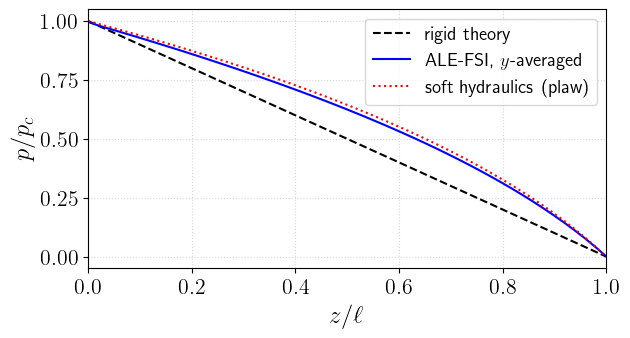

In [210]:
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c),
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c),
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c),
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
# ax.set_ylim(0, pressure_rigid[0]/float(p_c))
# ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
# ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

print(f"Reminder: compliance #, α = {alpha:.5f}")

plt.show()

## Fluid&ndash;solid interface displacement and pressure

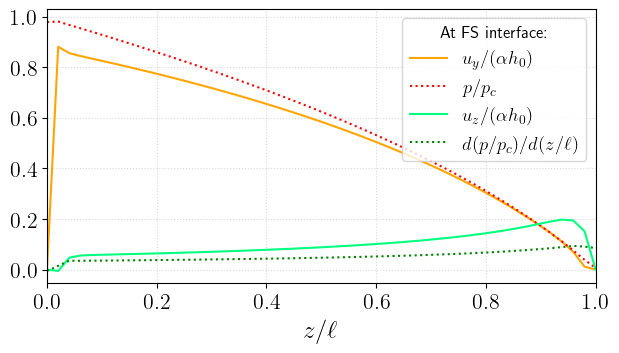

In [211]:
# Interpolators for u components (reuse p_interp from previous cell):
ux_plot = Function(V_plot)
uy_plot = Function(V_plot)
ux_plot.interpolate(Expression(u_out[0], V_plot.element.interpolation_points))
uy_plot.interpolate(Expression(u_out[1], V_plot.element.interpolation_points))
u_interp = LinearNDInterpolator(plot_coords,
                np.column_stack([ux_plot.x.array.real, uy_plot.x.array.real]))

# Create points along the fluid-solid interface:
# (offset down by ~1/N if needed, to ensure we're in the fluid domain)
xy_fs = np.column_stack([x_vals, np.full_like(x_vals, h0)])

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = u_interp(xy_fs)      # shape (N, 2): columns are [ux, uy]
p_fs_values = p_interp(xy_fs).ravel()

# d/dx and d2/dx2 axial derivatives via central differences, O(Δx²):
dpdx_fs     = np.gradient(p_fs_values, x_vals)
d2pdx2_fs   = np.gradient(dpdx_fs, x_vals)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, u_fs_values[:, 1]/float(alpha*h0),
        label=r'$u_y/(\alpha h_0)$', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c),
        label='$p/p_c$', color='red', linestyle='dotted')
ax.plot(x_vals/l, u_fs_values[:, 0]/float(alpha*h0),
        label=r'$u_z/(\alpha h_0)$', color='springgreen')
ax.plot(x_vals/l, -vartheta*dpdx_fs/(float(p_c)/l),
        label=r'$d(p/p_c)/d(z/\ell)$', color='green', linestyle='dotted')

ax.set_xlabel(r'$z/\ell$')
# ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(title="At FS interface:", title_fontsize='large')
ax.set_xlim(0, 1)
# ax.set_ylim(0, pressure_rigid[0]/float(p_c))
# ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
# ax.set_aspect(1)
ax.set_box_aspect(1 / 2)
plt.show()

## Pressure contours

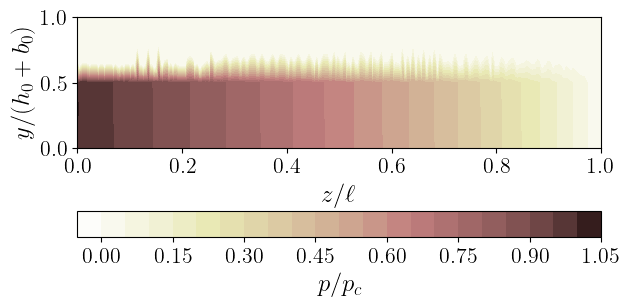

In [212]:
# Pressure nodal values in the plotting space:
p_plot = Function(V_plot)
p_plot.interpolate(p_out)
pressure_values = p_plot.x.array.real

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c),
                         levels=20, cmap='pink_r')
fig.colorbar(contour, label='$p/p_c$', orientation='horizontal')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

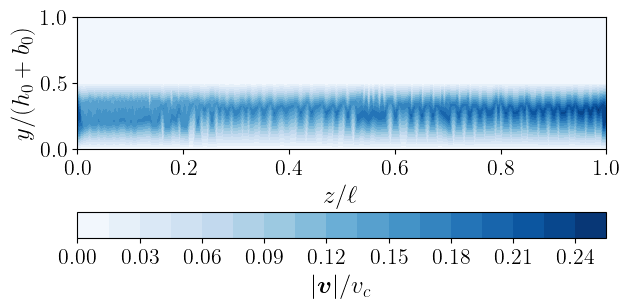

In [213]:
# Velocity magnitude nodal values in the plotting space:
vmag_plot = Function(V_plot)
vmag_expr = Expression(sqrt(dot(v_out, v_out)), V_plot.element.interpolation_points)
vmag_plot.interpolate(vmag_expr)
magnitude = vmag_plot.x.array.real

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c),
                         levels=20, cmap='Blues')
cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{v}|/v_c$')
else:
    cb.set_label(r'$|\vec{v}|/v_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We can mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

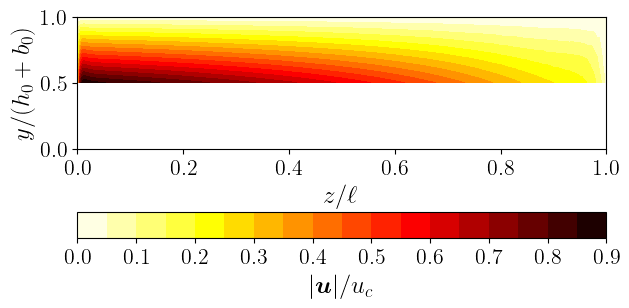

In [214]:
# Displacement magnitude nodal values in the plotting space:
umag_plot = Function(V_plot)
umag_expr = Expression(sqrt(dot(u_out, u_out)), V_plot.element.interpolation_points)
umag_plot.interpolate(umag_expr)
magnitude = umag_plot.x.array.real

# Mask off fluid domain, need to deep copy the triang:
masked_triang = tri.Triangulation(x_coords.copy(),
                                  y_coords.copy(),
                                  plot_cells.copy())
masked_triang.set_mask(
    np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(alpha*h0),
                         levels=20, cmap='hot_r')

cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{u}|/u_c$')
else:
    cb.set_label(r'$|\vec{u}|/u_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()